In [1]:
import requests

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
response = requests.get(url)

if response.status_code == 200:
    with open("BostonHousing.csv", "wb") as f:
        f.write(response.content)
    print("Saved BostonHousing.csv")
else:
    print("Failed:", response.status_code)


Saved BostonHousing.csv


In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('BostonHousing.csv')

In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


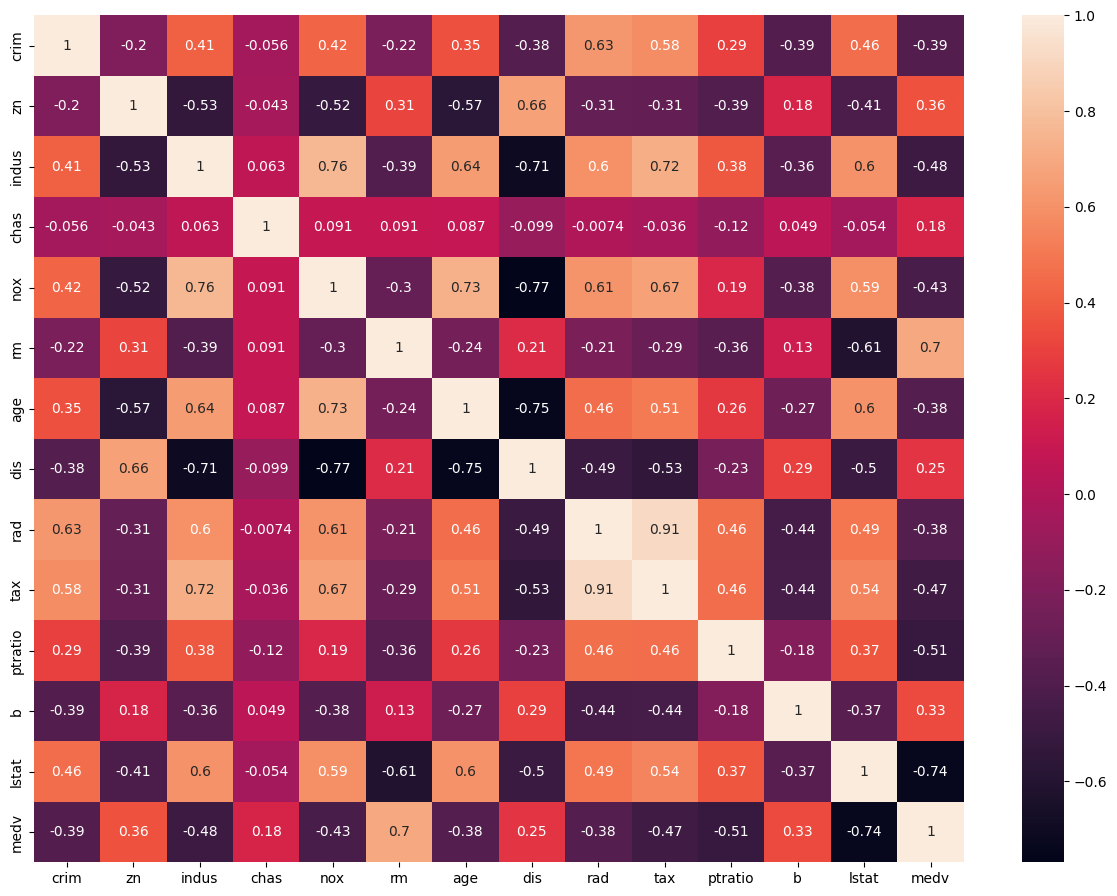

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 11))   # width, height in inches
sns.heatmap(df.corr(), annot=True)
plt.show()


Crim is highly corr with `rad` - **0.63** and `tax` **0.58**

Zn =>  `age` - **57**

indus => `nox` - **0.76**, `age` - **0.64**, `dis` - **0.71**, `rad` - **0.6 and** `tax` - **0.72** and `lastat` - **0.6**

nox => `age` - **0.73**, `dis` - **0.77**, `rad` - **0.61**, `tax` - **0.67** and `lstat` - **0.59**

rm => `islat` - **0.61** and `medv` - **0.7**

age => `dis` - **.75** 

rad => `tax` - **0.91**

istat => `medv` - **0.74**


In [13]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [7]:
import numpy as np 
correlation_matrix = df.corr()

In [29]:
# Example: Removing highly correlated features based on a threashold of 0.8 
threshold = 0.8 

# Identify the highly correlated feature pairs. 
high_corr_features = np.where(np.abs(correlation_matrix.values[:-1,:-1]) >= threshold)

# Create a set to store the features to remove
features_to_remove = set()

for i, j in zip(*high_corr_features):
    if i != j and i not in features_to_remove and j not in features_to_remove: 
        # Remove that feature whis has low correlation with target column
        features_to_remove.add(j if np.abs(correlation_matrix['medv']).iloc[i] > np.abs(correlation_matrix['medv']).iloc[j] else i)

In [30]:
features_to_remove

{8}

In [33]:
# Remove the feature from dataset 
df_filtered_corr = df.drop(df.columns[list(features_to_remove)], axis=1)

In [34]:
df_filtered_corr

,crim,zn,indus,chas,nox,rm,age,dis,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,273,21.0,393.45,6.48,22.0


In [31]:
list(features_to_remove)

[8]

In [32]:
df.columns[list(features_to_remove)]

Index(['rad'], dtype='object')

In [28]:
for i, j in zip(*high_corr_features): 
    if i != j: 
        print(i, j)

8 9
9 8


In [27]:
np.abs(correlation_matrix['medv'].iloc[0]) > np.abs(correlation_matrix['medv'].iloc[2])

False

In [25]:
correlation_matrix['medv'].iloc[0]

-0.38830460858681154

In [26]:
correlation_matrix['medv'].iloc[2]

-0.48372516002837285

In [19]:
np.where(np.abs(correlation_matrix.values[:-1,:-1]) >= threshold)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  8,  9,  9, 10, 11, 12]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  8,  9, 10, 11, 12]))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  8,  9,  9, 10, 11, 12]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  8,  9, 10, 11, 12]))

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


# VIF

To remove multicollinear columns using the Variance Inflation Factor (VIF)

- Calculate the VIF for each feature.

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(13):
    vif.append(variance_inflation_factor(df.iloc[:,:13], i))

In [41]:

VIF = pd.DataFrame({'vif': vif}, index=df.columns[:13]).T

In [42]:
VIF.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
vif,2.100373,2.844013,14.485758,1.152952,73.894947,77.948283,21.38685,14.699652,15.167725,61.227274,85.029547,20.104943,11.102025


In [38]:
VIF.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b'],
      dtype='object')

In [23]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Extract the independent variables (features) and target variable
X = df.drop('medv', axis=1)

# Calculate the VIF for each feature
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,crim,2.100373
1,zn,2.844013
2,indus,14.485758
3,chas,1.152952
4,nox,73.894947
5,rm,77.948283
6,age,21.386850
7,dis,14.699652
8,rad,15.167725
9,tax,61.227274


In [35]:
X = df.drop('medv', axis=1)

In [41]:
VIF = []
for i in range(X.shape[1]):
    print(round(variance_inflation_factor(X.values, i), 2))


2.1
2.84
14.49
1.15
73.89
77.95
21.39
14.7
15.17
61.23
85.03
20.1
11.1


### Analyze the VIF Values

Inspect the VIF values for each feature. Higher VIF values indicate a stronger multicollinearity. A commonly used threshold to detect multicollinearity is a VIF value greater than 5 or 10.

In [63]:
# Set the threshold for VIF 
vif_threshold = 5 

# Identify features with high VIF values
high_vif_features = vif[vif['VIF'] > vif_threshold]['Feature'].values

# Remove features with high VIF values from the dataset
df_filtered_vif = df.drop(high_vif_features, axis=1)

df_filtered_vif

,crim,zn,chas,medv
0,0.00632,18.0,0,24.0
1,0.02731,0.0,0,21.6
2,0.02729,0.0,0,34.7
3,0.03237,0.0,0,33.4
4,0.06905,0.0,0,36.2
...,...,...,...,...
501,0.06263,0.0,0,22.4
502,0.04527,0.0,0,20.6
503,0.06076,0.0,0,23.9
504,0.10959,0.0,0,22.0


In [61]:
vif[vif['VIF'] > vif_threshold]['Feature'].values

array(['indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b',
       'lstat'], dtype=object)

In [62]:
vif[vif['VIF'] > vif_threshold]['Feature'].values

array(['indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b',
       'lstat'], dtype=object)

In [57]:
vif['VIF'] > vif_threshold

0     False
1     False
2      True
3     False
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
Name: VIF, dtype: bool

## Droping `rad`

In [43]:
df.drop(columns='rad', inplace=True)

In [44]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   tax      506 non-null    int64  
 9   ptratio  506 non-null    float64
 10  b        506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


In [46]:
vif = []

for i in range(12):
    vif.append(variance_inflation_factor(df.iloc[:,:12], i))

VIF = pd.DataFrame({'vif': vif}, index=df.columns[:12]).T

In [47]:
VIF.head()

,crim,zn,indus,chas,nox,rm,age,dis,tax,ptratio,b,lstat
vif,1.958499,2.804841,13.396763,1.140431,73.874915,77.619949,21.323981,14.448391,22.603313,84.981547,19.528046,11.069456


# Condition Number

In [4]:
X = df.drop('medv', axis=1)

In [7]:
import numpy as np 

In [8]:
np.linalg.cond(X)

8497.936303845834

In [9]:
# Extract the independent variables (features) and target variable
X = df.drop('medv', axis=1)

# Calculate the condition number
condition_number = np.linalg.cond(X)
condition_number

8497.936303845834

- **Remove features with high condition number (if necessary). (>30)**

In [18]:
def remove_feature_condition_number(X, threshold): 
    condition_number = np.linalg.cond(X)
    if condition_number < threshold: 
        return X
    
    n_features = X.shape[1]
    for i in range(n_features): 
        X_temp = X.drop(X.columns[i], axis=1)
        condition_number_temp = np.linalg.cond(X_temp)
        if condition_number_temp < threshold: 
            return remove_feature_condition_number(X_temp, threshold)
        
    # If no subset of features satisfies the condition number threshold,
    # return the original features
    return X

In [19]:
# Set the threshold for condition number
condition_number_threshold = 30

# Remove features until the condition number falls below the threshold
df_filtered_condition_number = remove_feature_condition_number(X, condition_number_threshold)
df_filtered_condition_number

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [16]:
X.shape[1]

13

In [15]:
threshold = 30 
remove_feature_condition_number(X, threshold)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [20]:
# Calculate the condition number
condition_number = np.linalg.cond(df_filtered_condition_number)
condition_number

8497.936303845834

Refer these to colab to learn about it => https://colab.research.google.com/drive/13VhYm8xxjr92Cn1tYENAw6fFJYqBYDas?usp=sharing

https://colab.research.google.com/drive/1bCaiuxiKShosnKhaqDAE1lWXAi-_Fbb2?usp=sharing#scrollTo=28SKdkiIk9wy